In [1]:
# region Imports

#* --------------------------------------------------------------------------------
#* General purpose imports
#* --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact, barnard_exact
from matplotlib.ticker import FuncFormatter
import pickle as pkl


#* --------------------------------------------------------------------------------
#* Personal librairies imports
#* --------------------------------------------------------------------------------
import sys, os
src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import astro_utils as au
from utils import maths_utils  as mu
from utils import stats_utils  as su
from utils import graphics_utils  as gu
from utils import labels_utils  as lu
from utils import pandas_utils  as pu


#* --------------------------------------------------------------------------------
#* Project modules imports
#* --------------------------------------------------------------------------------
import sSFR
import generate_report as report
import domination

#* --------------------------------------------------------------------------------
#* Global variables
#* --------------------------------------------------------------------------------
import config as co

#* --------------------------------------------------------------------------------
#* Project data
#* --------------------------------------------------------------------------------

with open(co.DATA_PATH + co.PROCESS_SAMPLES, "rb") as file:
            sample = pkl.load(file)



# endregion

Done


In [2]:
sample['CG4'+co.GASUFF].columns

Index(['objid', 'specobjid', 'Group', 'RA', 'Dec', 'M_r', 'Lum', 'z',
       'dist2BGG', 'lgm', 'sfr', 'sSFR', 'rank_dist', 'rank_M', 'RA_BGG',
       'Dec_BGG', 'M_BGG', 'sSFR_status', 'p_E', 'p_S', 'is_dominated',
       'morphology', 'sSFR_raw', 'sSFR_MS_offset', 'MS_res', 'sSFR_excess'],
      dtype='object')

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import mannwhitneyu

GROUP_COL = "Group"
RANK_COL  = "rank_M"   # BGG si == 1
MASS_COL  = "lgm"      # log10(M*) ou équivalent

def clean_morph(s: pd.Series) -> pd.Series:
    """Garde seulement Spiral/Elliptical, met le reste à NaN (drop ensuite)."""
    return s.where(s.isin(["Spiral", "Elliptical"]))

def prep_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["morph_clean"] = clean_morph(df["morphology"])
    df["_is_bgg"] = df[RANK_COL].eq(1)
    # garde au moins les colonnes utiles
    return df

def group_level_binom(df: pd.DataFrame, control_lgm_bgg: bool = True):
    """
    Analyse au niveau groupe :
      k_sp_sat ~ Binomial(n_sat, p), logit(p) = b0 + b1*(BGG is Spiral) + b2*lgm_BGG(option)
    """
    df = prep_df(df)
    df = df.dropna(subset=[GROUP_COL, "morph_clean"])

    # BGG morph & masse par groupe
    bgg = df[df["_is_bgg"]].loc[:, [GROUP_COL, "morph_clean", MASS_COL]].dropna(subset=[GROUP_COL, "morph_clean"])
    bgg = bgg.rename(columns={"morph_clean": "bgg_morph", MASS_COL: "lgm_bgg"})

    # satellites only
    sat = df[~df["_is_bgg"]].copy()

    # stats satellites par groupe (en excluant Uncertain/NaN déjà)
    g = sat.groupby(GROUP_COL)
    grp = pd.DataFrame({
        "n_sat": g.size(),
        "k_sp_sat": g["morph_clean"].apply(lambda x: (x == "Spiral").sum())
    }).reset_index()

    grp = grp.merge(bgg, on=GROUP_COL, how="inner")
    grp = grp[grp["n_sat"] > 0].copy()

    grp["f_sp_sat"] = grp["k_sp_sat"] / grp["n_sat"]
    grp["bgg_is_sp"] = (grp["bgg_morph"] == "Spiral").astype(int)

    # GLM binomial pondéré (var_weights = n_sat)
    Xcols = ["bgg_is_sp"]
    if control_lgm_bgg and "lgm_bgg" in grp.columns:
        Xcols.append("lgm_bgg")

    X = sm.add_constant(grp[Xcols])
    y = grp["f_sp_sat"]
    w = grp["n_sat"]

    model = sm.GLM(y, X, family=sm.families.Binomial(), var_weights=w)
    res = model.fit()

    # Effet principal : bgg_is_sp
    beta = res.params["bgg_is_sp"]
    se   = res.bse["bgg_is_sp"]
    OR   = float(np.exp(beta))
    CI95 = (float(np.exp(beta - 1.96*se)), float(np.exp(beta + 1.96*se)))
    pval = float(res.pvalues["bgg_is_sp"])

    # Résumé médianes + MWU sur f_sp_sat
    a = grp.loc[grp["bgg_is_sp"]==1, "f_sp_sat"]
    b = grp.loc[grp["bgg_is_sp"]==0, "f_sp_sat"]
    p_mwu = float(mannwhitneyu(a, b, alternative="two-sided").pvalue) if (len(a)>0 and len(b)>0) else np.nan

    summary = {
        "n_groups_used": int(len(grp)),
        "median_fSp_sat_if_BGG_Sp": float(a.median()) if len(a) else np.nan,
        "median_fSp_sat_if_BGG_Ell": float(b.median()) if len(b) else np.nan,
        "OR_BGGSp_effect": OR,
        "CI95_OR": CI95,
        "p_glm": pval,
        "p_mwu": p_mwu,
        "controls": Xcols[1:]  # sans const
    }
    return summary, grp, res

def satellite_level_cluster(df: pd.DataFrame,
                            control_lgm_sat: bool = False,
                            control_lgm_bgg: bool = True):
    """
    Analyse au niveau satellites (1 ligne = 1 satellite),
    logit(P(Spiral_sat)) = a0 + a1*(BGG is Spiral) + covariables...
    SE clusterisées par Group.
    """
    df = prep_df(df)
    df = df.dropna(subset=[GROUP_COL, "morph_clean"])

    # BGG morph + lgm_bgg par groupe
    bgg = df[df["_is_bgg"]].loc[:, [GROUP_COL, "morph_clean", MASS_COL]].dropna(subset=[GROUP_COL, "morph_clean"])
    bgg = bgg.rename(columns={"morph_clean": "bgg_morph", MASS_COL: "lgm_bgg"})

    sat = df[~df["_is_bgg"]].copy()
    sat = sat.merge(bgg, on=GROUP_COL, how="inner")
    sat = sat.dropna(subset=["bgg_morph", "morph_clean"])

    sat["y_sp"] = (sat["morph_clean"] == "Spiral").astype(int)
    sat["bgg_is_sp"] = (sat["bgg_morph"] == "Spiral").astype(int)

    Xcols = ["bgg_is_sp"]
    if control_lgm_bgg and "lgm_bgg" in sat.columns:
        Xcols.append("lgm_bgg")
    if control_lgm_sat and MASS_COL in sat.columns:
        Xcols.append(MASS_COL)

    X = sm.add_constant(sat[Xcols])
    y = sat["y_sp"]

    model = sm.GLM(y, X, family=sm.families.Binomial())
    res = model.fit(cov_type="cluster", cov_kwds={"groups": sat[GROUP_COL]})

    beta = res.params["bgg_is_sp"]
    se   = res.bse["bgg_is_sp"]
    OR   = float(np.exp(beta))
    CI95 = (float(np.exp(beta - 1.96*se)), float(np.exp(beta + 1.96*se)))
    pval = float(res.pvalues["bgg_is_sp"])

    summary = {
        "n_sat_used": int(len(sat)),
        "n_groups_used": int(sat[GROUP_COL].nunique()),
        "OR_BGGSp_effect": OR,
        "CI95_OR": CI95,
        "p_cluster": pval,
        "controls": Xcols[1:]  # sans const
    }
    return summary, sat, res

# -----------------------------
# Boucle sur tes catégories
# -----------------------------
all_results = {}

for cat in co.SAMPLE.keys():
    key = cat + co.GASUFF
    if key not in sample:
        continue

    df = sample[key].copy()

    # garde seulement si les colonnes existent
    needed = {GROUP_COL, RANK_COL, "morphology", MASS_COL}
    if not needed.issubset(df.columns):
        missing = sorted(list(needed - set(df.columns)))
        all_results[cat] = {"error": f"Colonnes manquantes: {missing}"}
        continue

    # Groupe-level: contrôle lgm_BGG par défaut
    out_g, grp, res_g = group_level_binom(df, control_lgm_bgg=True)

    # Satellite-level: cluster par groupe, contrôle lgm_BGG, option lgm_sat
    out_s, sat, res_s = satellite_level_cluster(df, control_lgm_sat=False, control_lgm_bgg=True)

    all_results[cat] = {
        "group_level": out_g,
        "satellite_level_cluster": out_s,
    }

all_results

{'CG4': {'group_level': {'n_groups_used': 52,
   'median_fSp_sat_if_BGG_Sp': 0.3333333333333333,
   'median_fSp_sat_if_BGG_Ell': 0.3333333333333333,
   'OR_BGGSp_effect': 0.8900790967269001,
   'CI95_OR': (0.42277810248658604, 1.8738926963591038),
   'p_glm': 0.759168528700144,
   'p_mwu': 0.9839023840860037,
   'controls': ['lgm_bgg']},
  'satellite_level_cluster': {'n_sat_used': 140,
   'n_groups_used': 52,
   'OR_BGGSp_effect': 0.890079096730997,
   'CI95_OR': (0.4166969807948871, 1.9012395936399558),
   'p_cluster': 0.7636276741671504,
   'controls': ['lgm_bgg']}},
 'Control4B': {'group_level': {'n_groups_used': 597,
   'median_fSp_sat_if_BGG_Sp': 0.6666666666666666,
   'median_fSp_sat_if_BGG_Ell': 0.6666666666666666,
   'OR_BGGSp_effect': 1.1116417716387064,
   'CI95_OR': (0.8850242619178382, 1.3962864992810367),
   'p_glm': 0.3628634655472326,
   'p_mwu': 0.1230468342728902,
   'controls': ['lgm_bgg']},
  'satellite_level_cluster': {'n_sat_used': 1581,
   'n_groups_used': 597,
  

Refaire en séparant Dom et Non Dom

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import mannwhitneyu

# -----------------------------
# Config colonnes
# -----------------------------
GROUP_COL = "Group"
RANK_COL  = "rank_M"       # BGG si == 1
MASS_COL  = "lgm"          # log masse
DOM_COL   = "is_dominated" # dans la table GROUPES (cat + co.GRSUFF)

# -----------------------------
# Helpers
# -----------------------------
def clean_morph(s: pd.Series) -> pd.Series:
    """Garde seulement Spiral/Elliptical, le reste -> NaN (Uncertain, NaN)."""
    return s.where(s.isin(["Spiral", "Elliptical"]))

def attach_dom_from_group_table(df_gal: pd.DataFrame, df_grp: pd.DataFrame) -> pd.DataFrame:
    """
    IMPORTANT:
    - Cherche DOM_COL uniquement dans df_grp = sample[cat + co.GRSUFF]
    - Ajoute/écrase DOM_COL dans df_gal par mapping Group -> is_dominated
    """
    out = df_gal.copy()

    # mapping Group -> is_dominated (bool)
    dom_map = (
        df_grp[[GROUP_COL, DOM_COL]]
        .drop_duplicates(subset=[GROUP_COL])
        .set_index(GROUP_COL)[DOM_COL]
    )

    out[DOM_COL] = out[GROUP_COL].map(dom_map).astype("boolean")  # bool pandas
    return out

def prep_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["morph_clean"] = clean_morph(df["morphology"])
    df["_is_bgg"] = df[RANK_COL].eq(1)
    return df

# -----------------------------
# Stats : niveau groupe (binomial pondéré)
# -----------------------------
def group_level_binom(df: pd.DataFrame, control_lgm_bgg: bool = True):
    df = prep_df(df)
    df = df.dropna(subset=[GROUP_COL, "morph_clean"])

    # BGG morph + masse par groupe
    bgg = df[df["_is_bgg"]][[GROUP_COL, "morph_clean", MASS_COL]].dropna(subset=[GROUP_COL, "morph_clean"])
    bgg = bgg.rename(columns={"morph_clean": "bgg_morph", MASS_COL: "lgm_bgg"})

    # satellites
    sat = df[~df["_is_bgg"]].copy()

    # stats satellites par groupe
    g = sat.groupby(GROUP_COL)
    grp = pd.DataFrame({
        "n_sat": g.size(),
        "k_sp_sat": g["morph_clean"].apply(lambda x: (x == "Spiral").sum())
    }).reset_index()

    grp = grp.merge(bgg, on=GROUP_COL, how="inner")
    grp = grp[grp["n_sat"] > 0].copy()

    grp["f_sp_sat"] = grp["k_sp_sat"] / grp["n_sat"]
    grp["bgg_is_sp"] = (grp["bgg_morph"] == "Spiral").astype(int)

    # GLM binomial pondéré : y=f, var_weights=n_sat
    Xcols = ["bgg_is_sp"]
    if control_lgm_bgg and "lgm_bgg" in grp.columns:
        Xcols.append("lgm_bgg")

    X = sm.add_constant(grp[Xcols])
    y = grp["f_sp_sat"]
    w = grp["n_sat"]

    res = sm.GLM(y, X, family=sm.families.Binomial(), var_weights=w).fit()

    beta = res.params["bgg_is_sp"]
    se   = res.bse["bgg_is_sp"]
    OR   = float(np.exp(beta))
    CI95 = (float(np.exp(beta - 1.96*se)), float(np.exp(beta + 1.96*se)))
    pval = float(res.pvalues["bgg_is_sp"])

    # MWU sur f_sp_sat (optionnel)
    a = grp.loc[grp["bgg_is_sp"]==1, "f_sp_sat"]
    b = grp.loc[grp["bgg_is_sp"]==0, "f_sp_sat"]
    p_mwu = float(mannwhitneyu(a, b, alternative="two-sided").pvalue) if (len(a)>0 and len(b)>0) else np.nan

    return {
        "n_groups_used": int(len(grp)),
        "median_fSp_sat_BGGSp": float(a.median()) if len(a) else np.nan,
        "median_fSp_sat_BGGEll": float(b.median()) if len(b) else np.nan,
        "OR": OR,
        "CI95_low": CI95[0],
        "CI95_high": CI95[1],
        "p_glm": pval,
        "p_mwu": p_mwu,
    }

# -----------------------------
# Stats : niveau satellite, SE clusterisées par Group
# -----------------------------
def satellite_level_cluster(df: pd.DataFrame, control_lgm_bgg: bool = True, control_lgm_sat: bool = False):
    df = prep_df(df)
    df = df.dropna(subset=[GROUP_COL, "morph_clean"])

    # BGG morph + masse par groupe
    bgg = df[df["_is_bgg"]][[GROUP_COL, "morph_clean", MASS_COL]].dropna(subset=[GROUP_COL, "morph_clean"])
    bgg = bgg.rename(columns={"morph_clean": "bgg_morph", MASS_COL: "lgm_bgg"})

    sat = df[~df["_is_bgg"]].merge(bgg, on=GROUP_COL, how="inner")
    sat = sat.dropna(subset=["bgg_morph", "morph_clean"])

    sat["y_sp"] = (sat["morph_clean"] == "Spiral").astype(int)
    sat["bgg_is_sp"] = (sat["bgg_morph"] == "Spiral").astype(int)

    Xcols = ["bgg_is_sp"]
    if control_lgm_bgg and "lgm_bgg" in sat.columns:
        Xcols.append("lgm_bgg")
    if control_lgm_sat and MASS_COL in sat.columns:
        Xcols.append(MASS_COL)

    X = sm.add_constant(sat[Xcols])
    y = sat["y_sp"]

    res = sm.GLM(y, X, family=sm.families.Binomial()).fit(
        cov_type="cluster",
        cov_kwds={"groups": sat[GROUP_COL]}
    )

    beta = res.params["bgg_is_sp"]
    se   = res.bse["bgg_is_sp"]
    OR   = float(np.exp(beta))
    CI95 = (float(np.exp(beta - 1.96*se)), float(np.exp(beta + 1.96*se)))
    pval = float(res.pvalues["bgg_is_sp"])

    return {
        "n_sat_used": int(len(sat)),
        "n_groups_used": int(sat[GROUP_COL].nunique()),
        "OR": OR,
        "CI95_low": CI95[0],
        "CI95_high": CI95[1],
        "p_cluster": pval,
    }

# -----------------------------
# Boucle: cat, split dominated/non-dominated
# IMPORTANT: is_dominated lu dans cat+co.GRSUFF uniquement
# -----------------------------
rows = []

for cat in co.SAMPLE.keys():
    key_gal = cat + co.GASUFF   # galaxies
    key_grp = cat + co.GRSUFF   # groupes (is_dominated)

    if key_gal not in sample or key_grp not in sample:
        continue

    df_gal = sample[key_gal].copy()
    df_grp = sample[key_grp].copy()

    # Vérifs colonnes
    needed_gal = {GROUP_COL, RANK_COL, "morphology", MASS_COL}
    needed_grp = {GROUP_COL, DOM_COL}

    if not needed_gal.issubset(df_gal.columns):
        rows.append({"cat": cat, "dom": "ALL", "error": f"Missing in GAL: {sorted(list(needed_gal-set(df_gal.columns)))}"})
        continue
    if not needed_grp.issubset(df_grp.columns):
        rows.append({"cat": cat, "dom": "ALL", "error": f"Missing in GRP: {sorted(list(needed_grp-set(df_grp.columns)))}"})
        continue

    # Attache is_dominated depuis la table GROUPES
    df = attach_dom_from_group_table(df_gal, df_grp)

    # Split
    for dom_value, dom_label in [(True, "dominated"), (False, "non_dominated")]:
        dfi = df[df[DOM_COL] == dom_value].copy()

        # si trop peu de groupes, skip
        nG = dfi[GROUP_COL].nunique()
        if nG < 10:
            rows.append({"cat": cat, "dom": dom_label, "warning": f"too_few_groups ({nG})"})
            continue

        out_g = group_level_binom(dfi, control_lgm_bgg=True)
        out_s = satellite_level_cluster(dfi, control_lgm_bgg=True, control_lgm_sat=False)

        rows.append({
            "cat": cat,
            "dom": dom_label,

            "G_n_groups": out_g["n_groups_used"],
            "G_med_fSp_sat_BGGSp": out_g["median_fSp_sat_BGGSp"],
            "G_med_fSp_sat_BGGEll": out_g["median_fSp_sat_BGGEll"],
            "G_OR": out_g["OR"],
            "G_CI95": f"[{out_g['CI95_low']:.2f}, {out_g['CI95_high']:.2f}]",
            "G_p": out_g["p_glm"],
            "G_p_MWU": out_g["p_mwu"],

            "S_n_sat": out_s["n_sat_used"],
            "S_n_groups": out_s["n_groups_used"],
            "S_OR": out_s["OR"],
            "S_CI95": f"[{out_s['CI95_low']:.2f}, {out_s['CI95_high']:.2f}]",
            "S_p": out_s["p_cluster"],
        })

results_df = pd.DataFrame(rows)

# Mise en forme pour lecture
if len(results_df):
    results_df = results_df.sort_values(["cat", "dom"])
results_df

,cat,dom,G_n_groups,G_med_fSp_sat_BGGSp,G_med_fSp_sat_BGGEll,G_OR,G_CI95,G_p,G_p_MWU,S_n_sat,S_n_groups,S_OR,S_CI95,S_p
0,CG4,dominated,32,0.666667,0.333333,1.274640,"[0.43, 3.78]",0.661964,0.216704,88,32,1.274640,"[0.56, 2.90]",0.562974
1,CG4,non_dominated,20,0.333333,0.583333,0.533493,"[0.18, 1.61]",0.264298,0.229406,52,20,0.533493,"[0.16, 1.74]",0.296560
2,Control4B,dominated,165,1.000000,0.666667,1.841810,"[1.15, 2.95]",0.011147,0.009792,437,165,1.841810,"[1.12, 3.04]",0.016585
3,Control4B,non_dominated,432,0.666667,0.666667,0.929992,"[0.71, 1.21]",0.592947,0.907025,1144,432,0.929992,"[0.71, 1.22]",0.600729
4,Control4C,dominated,452,0.666667,0.500000,1.840049,"[1.39, 2.44]",0.000021,0.000001,1149,452,1.840049,"[1.38, 2.45]",0.000027
5,Control4C,non_dominated,182,0.666667,0.666667,0.888962,"[0.60, 1.33]",0.564258,0.975554,467,182,0.888962,"[0.57, 1.39]",0.604472
6,RG4,dominated,22,1.000000,0.666667,1.360954,"[0.34, 5.38]",0.660350,0.293773,57,22,1.360954,"[0.46, 4.02]",0.576872
7,RG4,non_dominated,25,0.666667,0.666667,0.593942,"[0.21, 1.68]",0.326667,0.162955,68,25,0.593942,"[0.25, 1.43]",0.243828


In [5]:
results_df.to_csv(co.OUTPUT_PATH + "morphology_by_domination.csv", index=False)

# Optical colours in compact groups: robustness exploration

The existing colour result suggests that CG4 satellites may be bluer than ordinary-group satellites at fixed stellar mass, despite compact groups having a more evolved overall galaxy population. The following exploratory tests ask whether that offset survives colour-selection effects and controls for redshift, sSFR class, morphology, galaxy role, distance to the BGG, and group dynamics.

The analysis is deliberately separate from the production report pipeline: it reads the already-loaded `sample` dictionary, does not overwrite existing results, and prints explicit skip messages when a requested quantity is unavailable.


In [6]:
# Shared setup for the colour exploration. Adjust these counts for faster/slower reruns.
from IPython.display import display
import importlib
import exploration_colour_robustness as ecr

ecr = importlib.reload(ecr)
RANDOM_SEED = 20260612
N_BOOT = 1000
N_PERM = 1000
N_GROUP_BOOT = 300

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


## 1. Data audit and colour construction

**Question.** Which catalogue rows have usable SDSS optical photometry, and are all physical covariates available for the same objects?

The cell below left-matches each galaxy catalogue to `sample["SDSS"]` by `objid`, preserving non-matches for the selection-bias analysis. It constructs the four colours from observed magnitudes, standardizes role/mass/redshift/sSFR/morphology fields, attaches group properties, and derives projected and group-normalized BGG distances when possible.


In [7]:
print("Galaxy catalogues used:")
for label, key in ecr.SAMPLE_KEYS.items():
    shape = sample[key].shape if key in sample else "missing"
    print(f"  {label:10s} <- sample[{key!r}]  shape={shape}")

colour_df = ecr.build_harmonized_colour_frame(sample)
colour_audit = ecr.colour_missingness_table(colour_df)
display(colour_audit)

harmonized_columns = [
    "sample", "is_CG4", "is_control", "is_RG4", "is_satellite", "is_BGG",
    "logM", "z_harmonized", "sSFR_harmonized", "sSFR_class",
    "morphology_harmonized", *ecr.COLOUR_COLUMNS, "dist2BGG",
    "dist2BGG_kpc", "norm_dist", "group_id", "Vdisp", "t_cr", "Class",
]
print("\nAvailable harmonized fields:")
print([column for column in harmonized_columns if column in colour_df.columns])


Galaxy catalogues used:
  CG4        <- sample['CG4_Gals']  shape=(248, 26)
  Control4B  <- sample['Control4B_Gals']  shape=(2792, 27)
  Control4C  <- sample['Control4C_Gals']  shape=(3004, 26)
  RG4        <- sample['RG4_Gals']  shape=(224, 27)


,sample,n_galaxies,n_all_four_colours,n_logM,n_z,n_sSFR_class,n_satellites_with_colours
0,CG4,248,110,234,248,248,102
1,Control4B,2792,931,2641,2792,2792,831
2,Control4C,3004,1478,2839,3004,3004,1369
3,RG4,224,102,219,224,224,92



Available harmonized fields:
['sample', 'is_CG4', 'is_control', 'is_RG4', 'is_satellite', 'is_BGG', 'logM', 'z_harmonized', 'sSFR_harmonized', 'sSFR_class', 'morphology_harmonized', 'u_minus_r', 'u_minus_g', 'g_minus_r', 'r_minus_i', 'dist2BGG', 'dist2BGG_kpc', 'norm_dist', 'group_id', 'Vdisp', 't_cr', 'Class']


## 2. Matched versus unmatched bias

**Question.** Are galaxies with all four colours representative of their parent catalogues?

Continuous variables are summarized with bootstrap median intervals, Mann-Whitney tests, and Cliff's delta. Categorical distributions use Fisher or chi-square tests with Cramer's V. The logistic model tests whether colour availability remains associated with sample or galaxy properties jointly.


Continuous matched/unmatched comparisons:


,sample,variable,n_matched,n_unmatched,median_matched,median_matched_ci_low,median_matched_ci_high,median_unmatched,median_unmatched_ci_low,median_unmatched_ci_high,median_diff_over_iqr,mannwhitney_p,cliffs_delta
3,CG4,M_r,110,138,-20.111690,-20.332857,-20.007211,-21.391936,-21.770535,-21.103640,0.722244,1.822597e-14,0.566667
0,CG4,logM,110,124,10.092590,9.987818,10.134205,10.732200,10.557325,10.829270,-0.781547,1.016657e-15,-0.608211
2,CG4,sSFR,110,124,-10.783163,-11.516316,-10.339127,-12.127909,-12.197866,-12.043210,0.700708,2.136525e-10,0.481378
1,CG4,z,110,138,0.036719,0.035231,0.037534,0.036441,0.034466,0.037375,0.031770,9.099170e-01,0.008432
7,Control4B,M_r,931,1861,-20.608104,-20.694700,-20.538657,-21.612288,-21.696583,-21.563175,0.688145,5.369578e-103,0.499530
4,Control4B,logM,931,1710,10.219080,10.175740,10.269302,10.828710,10.802999,10.850785,-0.811952,1.016865e-132,-0.576592
6,Control4B,sSFR,931,1710,-10.343328,-10.430707,-10.285143,-12.032494,-12.086967,-11.988727,0.956134,7.378521e-131,0.572474
5,Control4B,z,931,1861,0.035394,0.034804,0.036136,0.035013,0.034550,0.035523,0.035460,2.585796e-01,0.026189
11,Control4C,M_r,1478,1526,-19.557169,-19.620270,-19.506291,-21.504606,-21.654657,-21.336818,0.788944,3.152865e-175,0.594748
8,Control4C,logM,1459,1380,9.756942,9.718524,9.792975,10.733745,10.702735,10.812200,-0.799436,7.043332e-186,-0.630491


Categorical matched/unmatched comparisons:


,sample,variable,n,test,p_value,cramers_v,matched_fractions,unmatched_fractions
2,CG4,galaxy_role,248,Fisher exact,3.103889e-09,0.365509,"{'Satellite': 0.9272727272727272, 'BGG': 0.072...","{'Satellite': 0.6086956521739131, 'BGG': 0.391..."
0,CG4,morphology,248,chi-square,2.659779e-06,0.321755,"{'Spiral': 0.4818181818181818, 'Elliptical': 0...","{'Elliptical': 0.5217391304347826, 'Spiral': 0..."
1,CG4,sSFR_class,248,chi-square,3.889925e-07,0.345007,"{'Starforming': 0.509090909090909, 'Passive': ...","{'Passive': 0.6811594202898551, 'Starforming':..."
5,Control4B,galaxy_role,2792,Fisher exact,2.867111e-38,0.232909,"{'Satellite': 0.8925886143931256, 'BGG': 0.107...","{'Satellite': 0.6786673831273509, 'BGG': 0.321..."
3,Control4B,morphology,2792,chi-square,1.343080e-41,0.259644,"{'Spiral': 0.6262083780880774, 'Elliptical': 0...","{'Elliptical': 0.43901128425577646, 'Spiral': ..."
4,Control4B,sSFR_class,2792,chi-square,7.246801e-124,0.450676,"{'Starforming': 0.6659505907626209, 'Passive':...","{'Passive': 0.692101020956475, 'Starforming': ..."
8,Control4C,galaxy_role,3004,Fisher exact,1.712898e-115,0.400583,"{'Satellite': 0.9262516914749662, 'BGG': 0.073...","{'Satellite': 0.5792922673656619, 'BGG': 0.420..."
6,Control4C,morphology,3004,chi-square,1.210973e-39,0.244254,"{'Spiral': 0.5284167794316644, 'Elliptical': 0...","{'Elliptical': 0.44692005242463956, 'Spiral': ..."
7,Control4C,sSFR_class,3004,chi-square,5.669558e-112,0.412968,"{'Starforming': 0.5967523680649527, 'Passive':...","{'Passive': 0.6861074705111402, 'Starforming':..."
11,RG4,galaxy_role,224,Fisher exact,1.056526e-06,0.320886,"{'Satellite': 0.9019607843137255, 'BGG': 0.098...","{'Satellite': 0.6229508196721312, 'BGG': 0.377..."


Joint colour-availability logistic model (odds ratios):


,term,coefficient,odds_ratio,ci_low,ci_high,p_value
0,Intercept,19.899620,4.388289e+08,4.764978e+07,4.041378e+09,4.418168e-69
1,C(sample)[T.Control4B],-0.326633,7.213485e-01,5.271895e-01,9.870144e-01,4.118488e-02
2,C(sample)[T.Control4C],-0.163085,8.495188e-01,6.218164e-01,1.160603e+00,3.056426e-01
3,C(sample)[T.RG4],-0.504184,6.039984e-01,3.919235e-01,9.308300e-01,2.232532e-02
4,C(sSFR_class)[T.Quenched],-0.542663,5.811984e-01,2.994878e-01,1.127898e+00,1.086748e-01
5,C(sSFR_class)[T.Starforming],1.141509,3.131491e+00,2.667593e+00,3.676061e+00,2.964873e-44
6,C(morphology_harmonized)[T.Spiral],-0.323452,7.236465e-01,6.162304e-01,8.497865e-01,7.966812e-05
7,C(morphology_harmonized)[T.Uncertain],-1.902800,1.491503e-01,1.112933e-01,1.998847e-01,3.650005e-37
8,logM,-2.006385,1.344739e-01,1.103440e-01,1.638804e-01,5.573299e-88
9,z_harmonized,22.013526,3.633732e+09,3.423059e+05,3.857371e+13,3.250747e-06


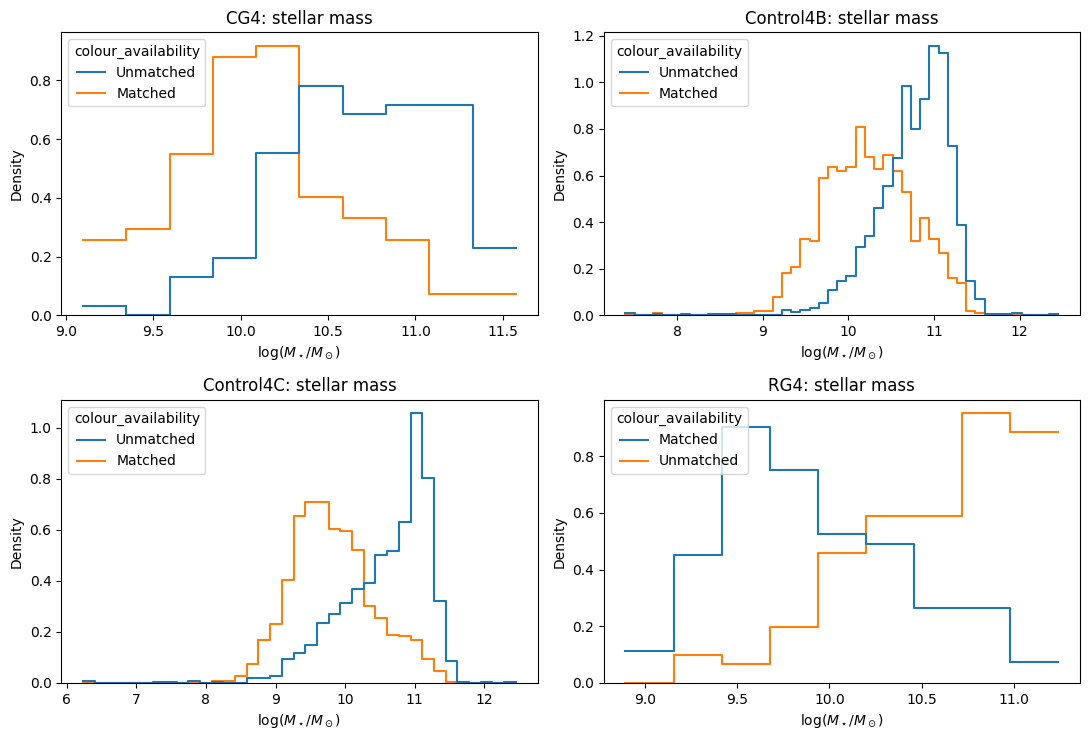

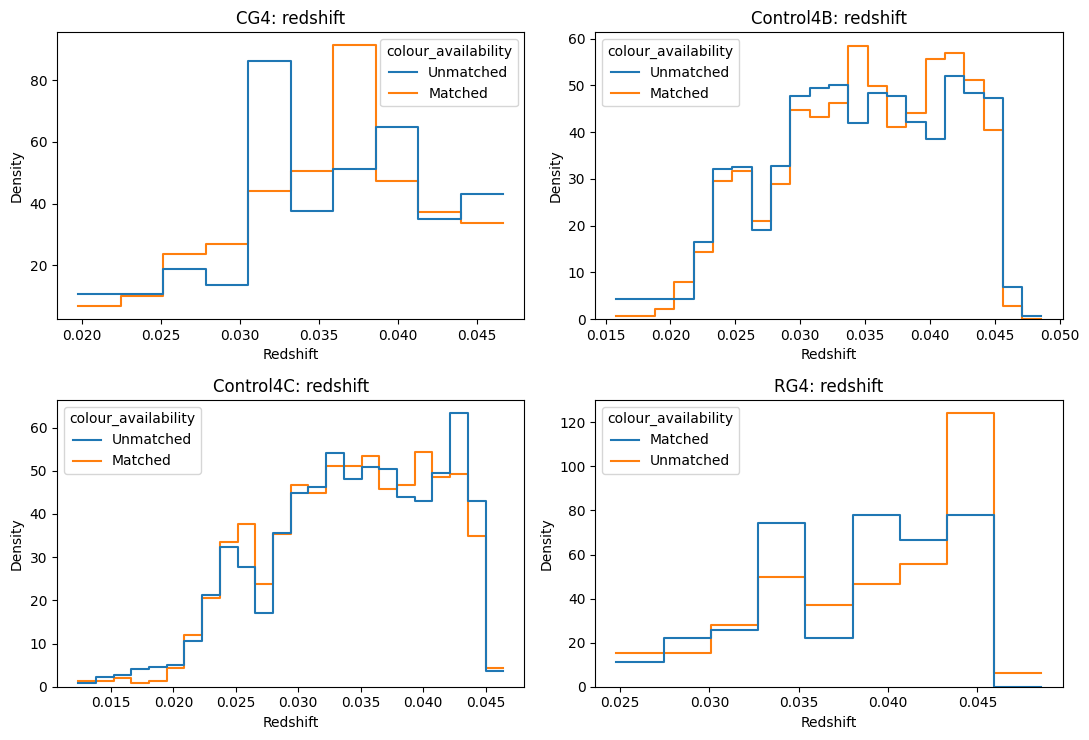

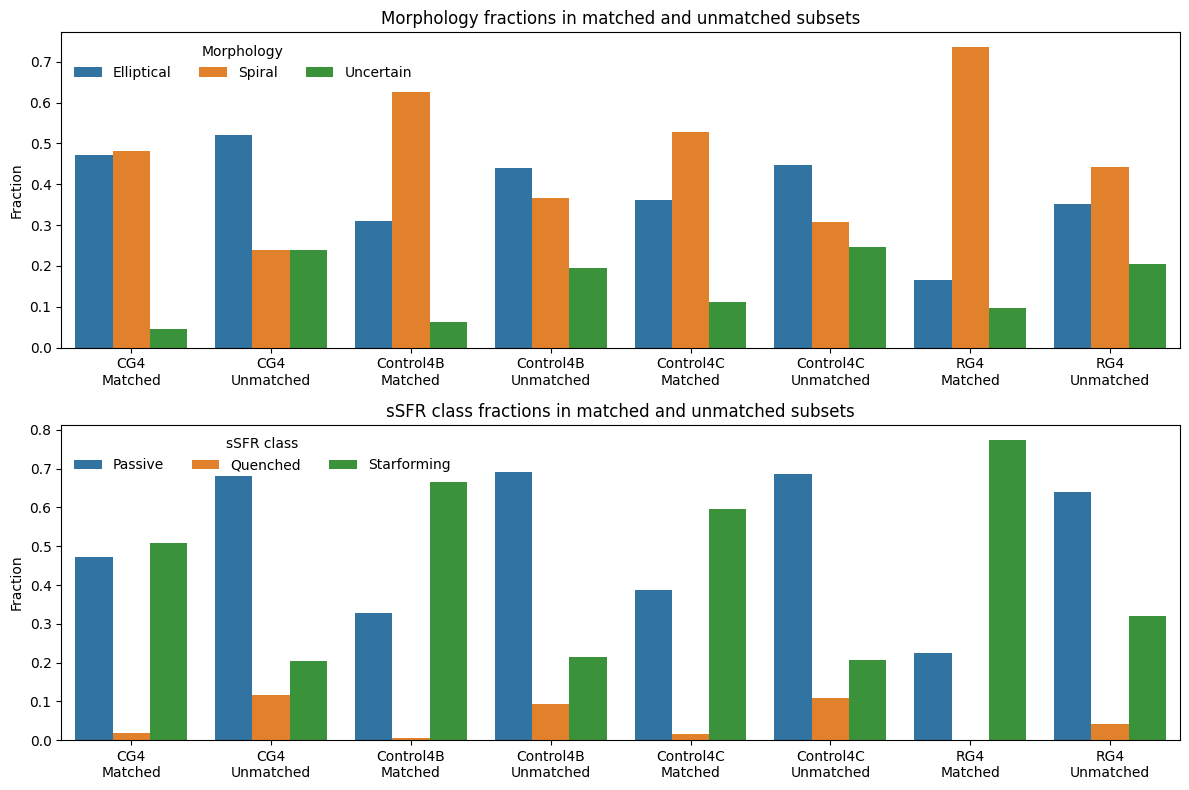

In [8]:
matching_continuous, matching_categorical = ecr.matching_bias_tests(
    colour_df,
    n_boot=N_BOOT,
)
colour_logit, colour_logit_table = ecr.fit_colour_availability_model(colour_df)

print("Continuous matched/unmatched comparisons:")
display(matching_continuous.sort_values(["sample", "variable"]))
print("Categorical matched/unmatched comparisons:")
display(matching_categorical.sort_values(["sample", "variable"]))
print("Joint colour-availability logistic model (odds ratios):")
display(colour_logit_table)

matching_fig_mass, matching_fig_z, matching_fig_categories = ecr.plot_matching_bias(colour_df)
plt.show()


## 3. Reference colour-mass-redshift residuals

**Question.** Relative to ordinary satellites with the same stellar mass and redshift, are CG4 galaxies systematically offset in colour?

For each colour, the baseline reference relation is fitted to pooled Control4B, Control4C, and RG4 satellites. A fuller reference additionally controls for morphology and sSFR class. Baseline residuals are stored as `delta_<colour>` and full residuals as `delta_<colour>_full`.


,colour,n_CG4,n_ordinary,median_CG4,median_ordinary,median_diff,ci68_low,ci68_high,ci95_low,ci95_high,mannwhitney_p,permutation_p,cliffs_delta
0,u_minus_r,102,2273,-0.054603,-0.113344,0.058741,0.010475,0.153600,-0.058169,0.208973,0.271583,0.393606,0.064262
4,u_minus_g,102,2273,-0.057612,-0.122851,0.065239,0.022239,0.094445,-0.029553,0.145764,0.248546,0.184815,0.067446
8,g_minus_r,102,2273,0.014189,0.001240,0.012950,0.002057,0.026280,-0.011865,0.037777,0.770784,0.494505,0.017033
12,r_minus_i,102,2273,0.008911,0.010570,-0.001659,-0.004355,0.005054,-0.007409,0.015795,0.848074,0.812188,-0.011201


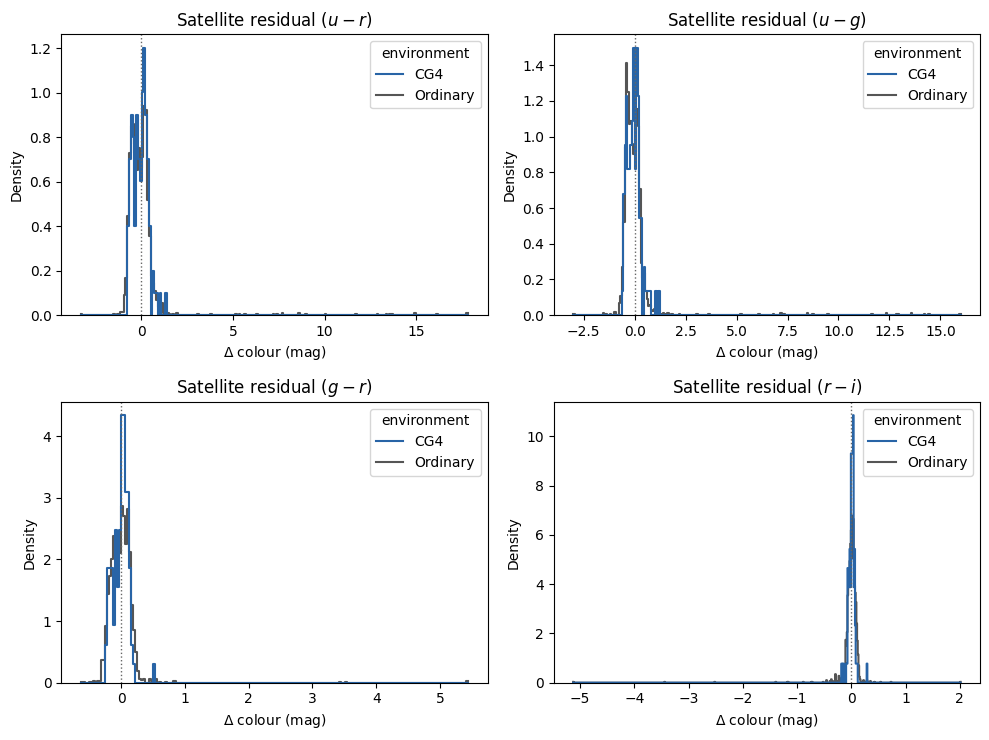

In [9]:
colour_df, colour_residual_models = ecr.make_colour_residuals(colour_df)
residual_comparison = ecr.compare_satellite_residuals(
    colour_df,
    n_boot=N_BOOT,
    n_perm=N_PERM,
)

pooled_residual_comparison = residual_comparison.loc[
    residual_comparison["comparison"] == "Ordinary pooled"
]
columns = [
    "colour", "n_CG4", "n_ordinary", "median_CG4", "median_ordinary",
    "median_diff", "ci68_low", "ci68_high", "ci95_low", "ci95_high",
    "mannwhitney_p", "permutation_p", "cliffs_delta",
]
display(pooled_residual_comparison[columns])
residual_distribution_figure = ecr.plot_satellite_residuals(colour_df)
plt.show()


## 4. Satellite-only comparison

**Question.** Does a CG4 coefficient remain after direct adjustment for mass and redshift, and after adding morphology and sSFR class?

The coefficient of `is_CG4` is CG4 minus ordinary colour: negative means bluer and positive means redder. Standard errors are clustered by catalogue-qualified group ID whenever enough groups are available. Results are shown for pooled ordinary satellites and for each comparison catalogue separately.


In [10]:
satellite_regressions = ecr.satellite_colour_regressions(colour_df)
display(
    satellite_regressions.sort_values(["comparison", "model", "colour"])
)


,comparison,colour,model,n,n_groups,is_CG4_coefficient,ci_low,ci_high,p_value
13,Control4B,g_minus_r,full,933,577,0.000906,-0.036462,0.038274,0.962112
15,Control4B,r_minus_i,full,933,577,0.011323,-0.002272,0.024918,0.102598
11,Control4B,u_minus_g,full,933,577,-0.080926,-0.213059,0.051208,0.229989
9,Control4B,u_minus_r,full,933,577,-0.080020,-0.235882,0.075842,0.314294
12,Control4B,g_minus_r,mass+redshift,933,577,0.044380,0.012483,0.076277,0.006392
14,Control4B,r_minus_i,mass+redshift,933,577,0.019131,0.005818,0.032444,0.004856
10,Control4B,u_minus_g,mass+redshift,933,577,0.044822,-0.049449,0.139093,0.351396
8,Control4B,u_minus_r,mass+redshift,933,577,0.089202,-0.026091,0.204494,0.129414
21,Control4C,g_minus_r,full,1452,738,-0.041981,-0.066713,-0.017249,0.000878
23,Control4C,r_minus_i,full,1452,738,-0.000802,-0.018987,0.017382,0.931109


## 5. Split by sSFR class

**Question.** Is any blue residual confined to the surviving star-forming satellites, or is it also present in passive/quenched systems?

A blue offset confined to star-forming satellites would support residual or interaction-triggered recent star formation. An offset in passive systems instead points toward rejuvenation, recent quenching, dust/metallicity effects, or classification systematics.


,split_value,colour,n_CG4,n_ordinary,median_diff,ci95_low,ci95_high,permutation_p,cliffs_delta
8,Passive,g_minus_r,45,749,-0.031924,-0.055052,0.002807,0.032967,-0.222608
12,Passive,r_minus_i,45,749,-0.009626,-0.026067,-0.001259,0.293706,-0.191159
4,Passive,u_minus_g,45,749,-0.012347,-0.042863,0.050433,0.620380,-0.013559
0,Passive,u_minus_r,45,749,-0.028317,-0.094828,0.060866,0.378621,-0.072304
24,Starforming,g_minus_r,55,1517,-0.003122,-0.050590,0.039287,0.866134,-0.037298
28,Starforming,r_minus_i,55,1517,0.006993,-0.013452,0.018496,0.505495,0.018338
20,Starforming,u_minus_g,55,1517,-0.004502,-0.087170,0.084325,0.948052,-0.024115
16,Starforming,u_minus_r,55,1517,0.027794,-0.125484,0.133842,0.635365,-0.023851


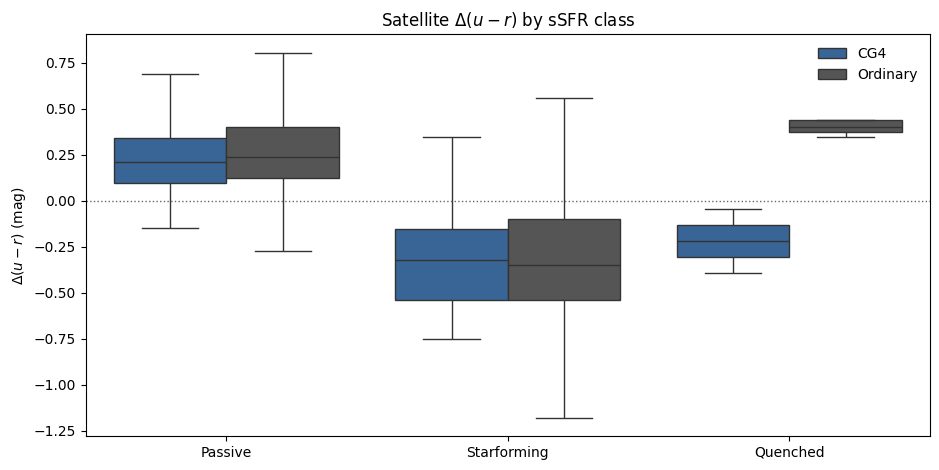

In [11]:
ssfr_split_comparison = ecr.compare_satellite_residuals(
    colour_df,
    split_column="sSFR_class",
    n_boot=N_BOOT,
    n_perm=N_PERM,
)
ssfr_pooled = ssfr_split_comparison.loc[
    ssfr_split_comparison["comparison"] == "Ordinary pooled"
]
display(
    ssfr_pooled[[
        "split_value", "colour", "n_CG4", "n_ordinary", "median_diff",
        "ci95_low", "ci95_high", "permutation_p", "cliffs_delta",
    ]].sort_values(["split_value", "colour"])
)
ssfr_residual_figure = ecr.plot_residuals_by_category(
    colour_df,
    category="sSFR_class",
    title=r"Satellite $\Delta(u-r)$ by sSFR class",
)
plt.show()


## 6. Split by morphology

**Question.** Is the apparent colour offset only a consequence of CG4 having a different elliptical/spiral mixture?

Residual comparisons are repeated within elliptical, spiral, and uncertain classes. The interaction model tests whether the CG4 coefficient itself changes with morphology.


,split_value,colour,n_CG4,n_ordinary,median_diff,ci95_low,ci95_high,permutation_p,cliffs_delta
8,Elliptical,g_minus_r,46,683,-0.035605,-0.055640,-0.010407,0.048951,-0.209848
12,Elliptical,r_minus_i,46,683,-0.011701,-0.026622,0.001396,0.220779,-0.161723
4,Elliptical,u_minus_g,46,683,-0.007413,-0.120946,0.056429,0.814186,-0.039181
0,Elliptical,u_minus_r,46,683,-0.053498,-0.138926,0.038715,0.172827,-0.092208
24,Spiral,g_minus_r,51,1367,0.010913,-0.049245,0.061367,0.703297,0.017428
28,Spiral,r_minus_i,51,1367,0.009338,-0.012046,0.035236,0.441558,0.046603
20,Spiral,u_minus_g,51,1367,0.044484,-0.090699,0.128006,0.398601,0.007989
16,Spiral,u_minus_r,51,1367,0.075903,-0.157553,0.156149,0.309690,0.019464
40,Uncertain,g_minus_r,5,223,-0.092066,-0.215918,0.043329,0.400599,-0.305830
44,Uncertain,r_minus_i,5,223,-0.016643,-0.162876,-0.003310,0.678322,-0.388341


Morphology-adjusted and interaction terms:


,colour,model,term,coefficient,ci_low,ci_high,p_value,n
0,u_minus_r,morphology_adjusted,is_CG4_numeric,-0.112446,-0.207162,-0.017730,0.019973,2375
1,u_minus_r,morphology_interaction,is_CG4_numeric,-0.212371,-0.366228,-0.058513,0.006823,2375
2,u_minus_r,morphology_interaction,is_CG4_numeric:C(morphology_harmonized)[T.Spiral],0.190110,-0.006001,0.386221,0.057434,2375
3,u_minus_r,morphology_interaction,is_CG4_numeric:C(morphology_harmonized)[T.Unce...,0.069845,-0.435173,0.574864,0.786339,2375
4,u_minus_g,morphology_adjusted,is_CG4_numeric,-0.091438,-0.170621,-0.012256,0.023616,2375
5,u_minus_g,morphology_interaction,is_CG4_numeric,-0.163420,-0.299596,-0.027243,0.018670,2375
6,u_minus_g,morphology_interaction,is_CG4_numeric:C(morphology_harmonized)[T.Spiral],0.131693,-0.037048,0.300433,0.126105,2375
7,u_minus_g,morphology_interaction,is_CG4_numeric:C(morphology_harmonized)[T.Unce...,0.103430,-0.344245,0.551105,0.650674,2375
8,g_minus_r,morphology_adjusted,is_CG4_numeric,-0.021008,-0.048134,0.006119,0.129045,2375
9,g_minus_r,morphology_interaction,is_CG4_numeric,-0.048951,-0.082620,-0.015282,0.004378,2375


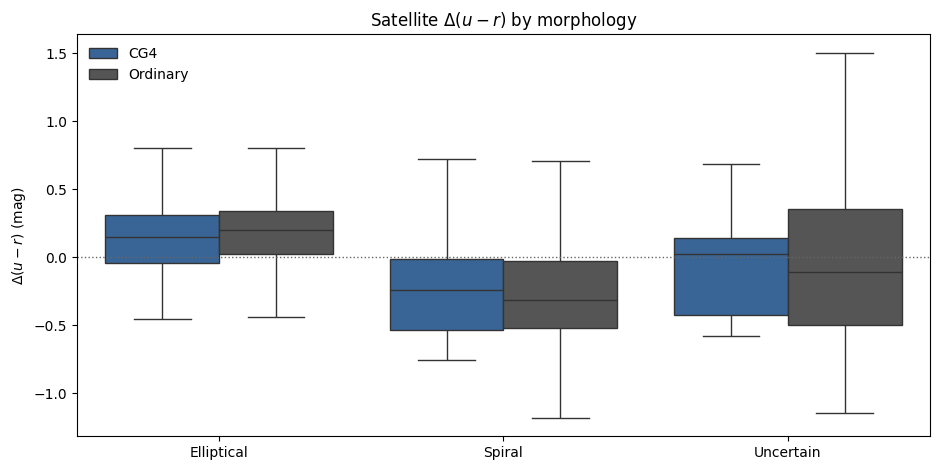

In [12]:
morphology_split_comparison = ecr.compare_satellite_residuals(
    colour_df,
    split_column="morphology_harmonized",
    n_boot=N_BOOT,
    n_perm=N_PERM,
)
morphology_pooled = morphology_split_comparison.loc[
    morphology_split_comparison["comparison"] == "Ordinary pooled"
]
morphology_regressions = ecr.morphology_colour_regressions(colour_df)

display(
    morphology_pooled[[
        "split_value", "colour", "n_CG4", "n_ordinary", "median_diff",
        "ci95_low", "ci95_high", "permutation_p", "cliffs_delta",
    ]].sort_values(["split_value", "colour"])
)
print("Morphology-adjusted and interaction terms:")
display(morphology_regressions)

morphology_residual_figure = ecr.plot_residuals_by_category(
    colour_df,
    category="morphology_harmonized",
    title=r"Satellite $\Delta(u-r)$ by morphology",
)
plt.show()


## 7. Colour residuals versus distance to the BGG

**Question.** Do colour residuals vary across the group, as expected for central environmental processing, recent infall, or interaction-triggered star formation?

The analysis reports Pearson and Spearman correlations by sample, fits within-sample distance models adjusted for mass and redshift, and tests a pooled `is_CG4 × distance` interaction. Both projected kpc and group-normalized distances are used when available.


Correlations with nominal p < 0.05 (exploratory; not multiple-test corrected):


,sample,distance,colour,n,pearson_r,pearson_p,spearman_rho,spearman_p
32,CG4,dist2BGG,g_minus_r,102,-0.330912,6.810587e-04,-0.297703,2.375157e-03
33,Control4B,dist2BGG,g_minus_r,831,-0.145104,2.682614e-05,-0.228553,2.610220e-11
34,Control4C,dist2BGG,g_minus_r,1350,-0.185959,5.723074e-12,-0.323528,2.889493e-34
35,RG4,dist2BGG,g_minus_r,92,-0.219598,3.544344e-02,-0.215264,3.932794e-02
28,CG4,dist2BGG,u_minus_g,102,-0.379908,8.205573e-05,-0.344194,3.967753e-04
29,Control4B,dist2BGG,u_minus_g,831,-0.103749,2.750169e-03,-0.166817,1.327965e-06
30,Control4C,dist2BGG,u_minus_g,1350,-0.130633,1.464870e-06,-0.342623,1.769712e-38
24,CG4,dist2BGG,u_minus_r,102,-0.411197,1.761125e-05,-0.392189,4.568490e-05
25,Control4B,dist2BGG,u_minus_r,831,-0.120362,5.068283e-04,-0.195469,1.337576e-08
26,Control4C,dist2BGG,u_minus_r,1350,-0.153613,1.406547e-08,-0.363912,1.551052e-43


Distance-model terms with nominal p < 0.05:


,sample,distance,colour,model,term,coefficient,p_value
0,CG4,dist2BGG_kpc,u_minus_r,within_sample,dist2BGG_kpc,-0.001771,2.857751e-04
1,Control4B,dist2BGG_kpc,u_minus_r,within_sample,dist2BGG_kpc,-0.000376,1.833380e-03
2,Control4C,dist2BGG_kpc,u_minus_r,within_sample,dist2BGG_kpc,-0.001367,7.754707e-07
4,Pooled interaction,dist2BGG_kpc,u_minus_r,CG4_distance_interaction,is_CG4_numeric:dist2BGG_kpc,-0.001509,5.079230e-03
5,CG4,dist2BGG_kpc,u_minus_g,within_sample,dist2BGG_kpc,-0.001369,9.242268e-04
6,Control4B,dist2BGG_kpc,u_minus_g,within_sample,dist2BGG_kpc,-0.000252,6.519482e-03
7,Control4C,dist2BGG_kpc,u_minus_g,within_sample,dist2BGG_kpc,-0.001073,2.132607e-05
9,Pooled interaction,dist2BGG_kpc,u_minus_g,CG4_distance_interaction,is_CG4_numeric:dist2BGG_kpc,-0.001230,9.396850e-03
10,CG4,dist2BGG_kpc,g_minus_r,within_sample,dist2BGG_kpc,-0.000402,1.195326e-02
11,Control4B,dist2BGG_kpc,g_minus_r,within_sample,dist2BGG_kpc,-0.000124,1.974888e-04


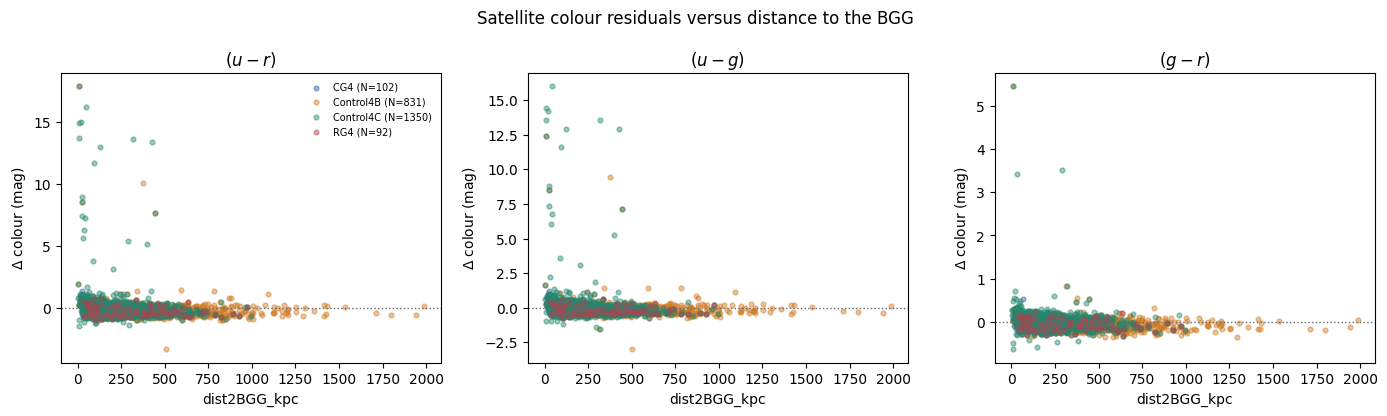

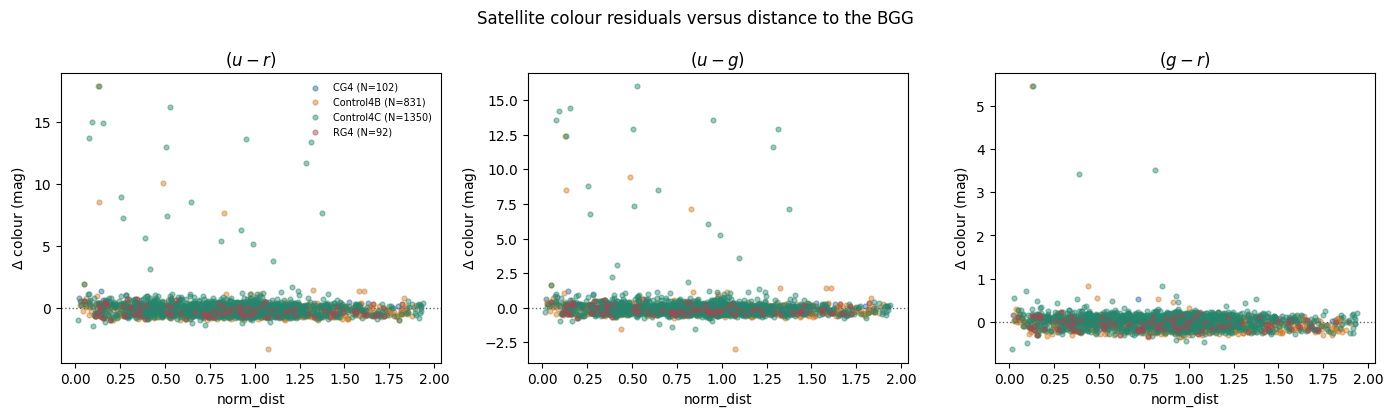

In [13]:
distance_correlations, distance_models = ecr.distance_colour_analysis(colour_df)
print("Correlations with nominal p < 0.05 (exploratory; not multiple-test corrected):")
display(distance_correlations.loc[
    (distance_correlations["pearson_p"] < 0.05)
    | (distance_correlations["spearman_p"] < 0.05)
].sort_values(["distance", "colour", "sample"]))
print("Distance-model terms with nominal p < 0.05:")
display(distance_models.loc[distance_models["p_value"] < 0.05])

for distance_name in ["dist2BGG_kpc", "norm_dist"]:
    distance_figure = ecr.plot_distance_residuals(colour_df, distance=distance_name)
    if distance_figure is not None:
        plt.show()


## 8. Group-level colour quantities

**Question.** Are groups with shorter crossing times, larger velocity dispersions, different masses/luminosities, BGG offsets, domination, or CG class systematically different in their satellite colours?

For each group, the code computes mean/median satellite residual, the fraction with `delta_u_minus_r < -0.1`, and intra-group residual scatter. Spearman intervals are bootstrapped by group. Only the three crossing-time plots most directly tied to the evolutionary interpretation are shown.


Nominal group-level correlations with p < 0.05:


,sample,outcome,group_quantity,n_groups,spearman_rho,ci95_low,ci95_high,p_value
5,All,mean_delta_u_minus_r,Offset_Bary,1312,-0.104161,-0.158399,-0.050742,1.571079e-04
1,All,mean_delta_u_minus_r,Vdisp,1312,0.205472,0.154515,0.257741,5.658495e-14
0,All,mean_delta_u_minus_r,t_cr,627,-0.191368,-0.264519,-0.110411,1.386275e-06
12,All,median_delta_u_minus_r,Offset_Bary,1312,-0.110105,-0.164790,-0.055914,6.427906e-05
8,All,median_delta_u_minus_r,Vdisp,1312,0.201029,0.152354,0.254959,1.985370e-13
7,All,median_delta_u_minus_r,t_cr,627,-0.171422,-0.247638,-0.089064,1.590175e-05
19,All,satellite_blue_fraction,Offset_Bary,1312,0.099722,0.048277,0.153849,2.972965e-04
15,All,satellite_blue_fraction,Vdisp,1312,-0.183476,-0.237425,-0.135514,2.136640e-11
14,All,satellite_blue_fraction,t_cr,627,0.181178,0.100805,0.255141,4.983483e-06
30,CG4,mean_delta_u_minus_r,Lum_group,53,0.283100,0.011707,0.532322,3.996791e-02


CG4 class summary:


,Class,n_groups,mean_delta_u_minus_r,satellite_blue_fraction,colour_scatter
0,Embedded,33,-0.040384,0.500000,0.178920
1,Isolated,5,-0.418598,0.500000,0.337842
2,Predom,15,0.005356,0.333333,0.242689


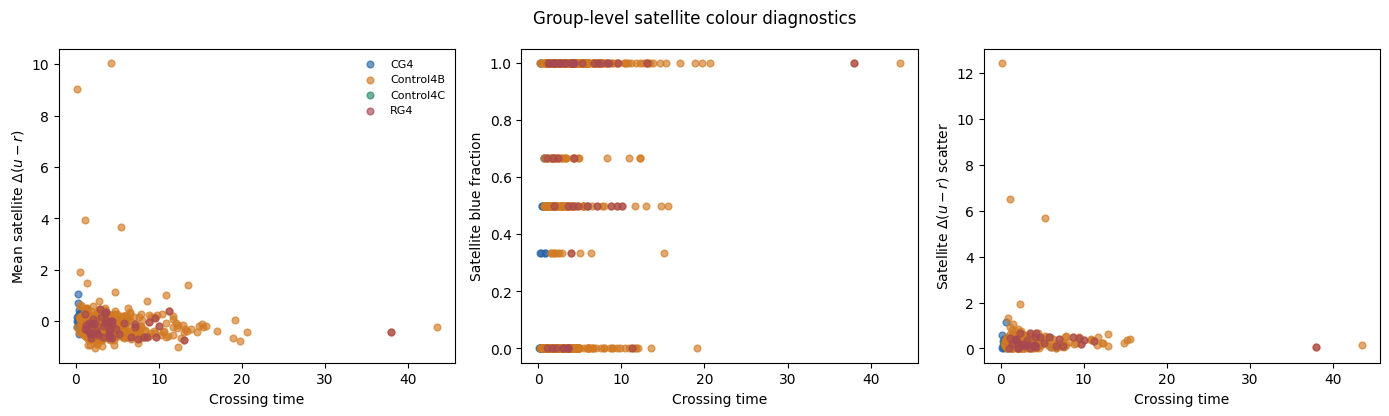

In [14]:
group_colour_summary = ecr.build_group_colour_summary(colour_df)
group_colour_correlations = ecr.group_colour_correlations(
    group_colour_summary,
    n_boot=N_BOOT,
)
cg_class_colour_summary = ecr.group_class_summary(group_colour_summary)

print("Nominal group-level correlations with p < 0.05:")
display(group_colour_correlations.loc[
    group_colour_correlations["p_value"] < 0.05
].sort_values(["sample", "outcome", "group_quantity"]))
print("CG4 class summary:")
display(cg_class_colour_summary)

group_dynamics_figure = ecr.plot_group_colour_dynamics(group_colour_summary)
if group_dynamics_figure is not None:
    plt.show()


## 9. Colour-sSFR consistency plane

**Question.** Which galaxies have colours inconsistent with their current sSFR or morphology?

The diagnostic flags blue low-sSFR objects (recently quenched/post-starburst candidates), red high-sSFR objects (possible dust-obscured star formation), blue ellipticals, and red spirals. Thresholds use colour residuals rather than raw colours so that stellar mass and redshift trends are removed first.


outlier_class,blue + low sSFR,blue elliptical,red + high sSFR,red spiral
sample,,,,
CG4,2,8,6,11
Control4B,14,43,56,79
Control4C,13,56,139,164
RG4,1,3,10,12


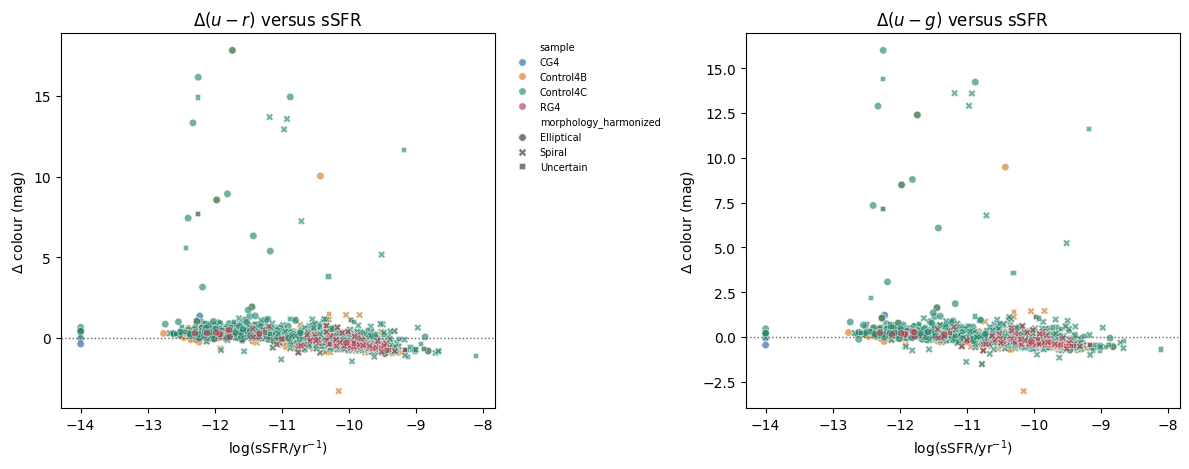

In [15]:
colour_ssfr_outlier_counts = ecr.colour_ssfr_outliers(colour_df)
display(colour_ssfr_outlier_counts.pivot(
    index="sample",
    columns="outlier_class",
    values="count",
).fillna(0).astype(int))

colour_ssfr_figure = ecr.plot_colour_ssfr_plane(colour_df)
plt.show()


## 10. Robustness checks

**Question.** Does the inferred CG4 coefficient survive common-support cuts, morphology/outlier exclusions, alternative controls, group bootstrap resampling, and removal of any one CG4 group?

The primary coefficient is re-estimated in the common mass and redshift ranges, without uncertain morphologies, after conservative residual trimming, and against each control catalogue separately. Group bootstrap intervals respect within-group dependence. Leave-one-CG4-group-out estimates reveal whether a small number of systems dominate the result.


,check,comparison,colour,n,coefficient,ci_low,ci_high,p_value
18,baseline,Ordinary pooled,g_minus_r,2375,-0.002973,-0.031580,0.025634,0.838583
26,bootstrap by group,Ordinary pooled,g_minus_r,2375,-0.004083,-0.031439,0.024267,0.746667
20,common redshift range,Ordinary pooled,g_minus_r,2355,-0.003116,-0.031694,0.025461,0.830747
19,common stellar-mass range,Ordinary pooled,g_minus_r,2220,-0.004745,-0.033951,0.024461,0.750157
21,exclude uncertain morphology,Ordinary pooled,g_minus_r,2147,0.003269,-0.026136,0.032674,0.827510
23,separate control,Control4B,g_minus_r,933,0.044380,0.012483,0.076277,0.006392
24,separate control,Control4C,g_minus_r,1452,-0.040323,-0.070734,-0.009913,0.009354
25,separate control,RG4,g_minus_r,194,0.034891,-0.002194,0.071976,0.065182
22,trim residual 0.5%-99.5%,Ordinary pooled,g_minus_r,2353,0.006554,-0.020569,0.033678,0.635771
27,baseline,Ordinary pooled,r_minus_i,2375,0.007705,-0.007023,0.022434,0.305179


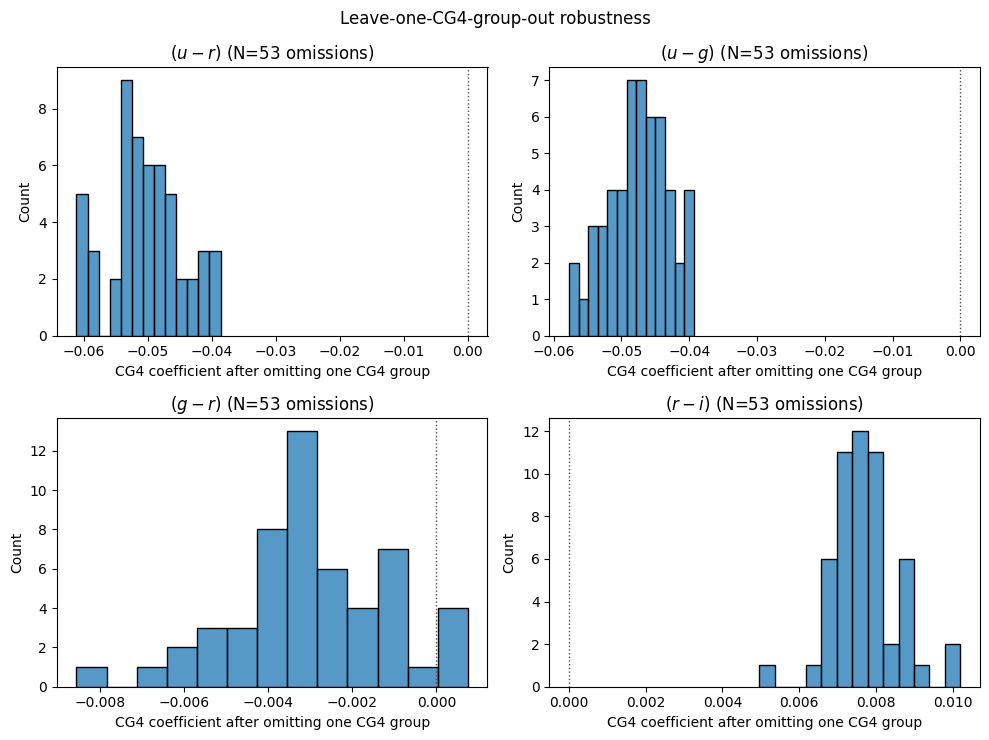

In [16]:
robustness_table, leave_one_group_out = ecr.robustness_checks(
    colour_df,
    n_group_boot=N_GROUP_BOOT,
)
display(robustness_table.sort_values(["colour", "check", "comparison"]))

leave_one_group_figure = ecr.plot_leave_one_group_out(leave_one_group_out)
if leave_one_group_figure is not None:
    plt.show()


## 11. Machine-generated output summary

The summary below is intentionally conservative and based on nominal 5% thresholds. It should be read together with effect sizes, confidence intervals, sample sizes, and the large number of exploratory comparisons above.


In [17]:
colour_exploration_summary = ecr.make_machine_summary(
    matching_continuous,
    matching_categorical,
    satellite_regressions,
    ssfr_split_comparison,
    morphology_split_comparison,
    distance_correlations,
    robustness_table,
)
print(colour_exploration_summary)


Colour exploration summary:

1. The colour-matched subset appears potentially biased with respect to the audited galaxy properties.
2. At fixed mass and redshift, CG4 satellites are not significantly bluer in the pooled comparison.
3. After controlling for sSFR class and morphology, a negative offset emerges in u_minus_r, u_minus_g, g_minus_r.
4. Significant negative residual differences by sSFR class occur in Passive; by morphology they occur in Elliptical.
5. CG4 colour residuals do show a nominal Spearman correlation with BGG distance.
6. Preferred interpretation: A negative coefficient appears only after population controls and is not stable in the baseline pooled robustness checks. Because the split signal is not concentrated in star-forming spirals, interaction-triggered star formation is not the preferred explanation; selection, control-sample heterogeneity, rejuvenation, dust/metallicity, or classification effects require investigation.
7. Main caveats: SDSS colour matching, sm